# DS 4320 Project 1: Predicting Next-Day Market Direction

## Data Preparation

This section loads the relational dataset into DuckDB using Python and joins the tables into a single modeling dataset.

In [12]:
import duckdb
import pandas as pd
import os
import logging

# Paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(BASE_DIR, "Data")
LOG_DIR = os.path.join(BASE_DIR, "logs")
DB_PATH = os.path.join(BASE_DIR, "project.duckdb")

os.makedirs(LOG_DIR, exist_ok=True)

# Logging setup
LOG_FILE = os.path.join(LOG_DIR, "pipeline.log")

logging.basicConfig(
    filename=LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logger = logging.getLogger()

# File paths
FILES = {
    "prices": os.path.join(DATA_DIR, "prices.parquet"),
    "returns": os.path.join(DATA_DIR, "returns.parquet"),
    "technical_indicators": os.path.join(DATA_DIR, "technical_indicators.parquet"),
    "targets": os.path.join(DATA_DIR, "targets.parquet"),
}

# Debug info
#print("Current working directory:", os.getcwd())
#print("Project base directory:", BASE_DIR)
#print("Data directory:", DATA_DIR)
#print("Log file:", LOG_FILE)

# Check files exist
try:
    for name, path in FILES.items():
        if not os.path.exists(path):
            logger.error(f"Missing file: {path}")
            raise FileNotFoundError(f"{path} not found. Run build_dataset.py first.")
    logger.info("All required parquet files were found.")
except Exception as e:
    logger.critical(f"File check failed: {e}")
    raise

# Connect to DuckDB
try:
    con = duckdb.connect(DB_PATH)
    logger.info(f"Connected to DuckDB at {DB_PATH}")
except Exception as e:
    logger.critical(f"DuckDB connection failed: {e}")
    raise

# Load tables into DuckDB
try:
    for table, path in FILES.items():
        con.execute(f"DROP TABLE IF EXISTS {table}")
        con.execute(f"CREATE TABLE {table} AS SELECT * FROM read_parquet('{path}')")
        logger.info(f"Loaded table {table} from {path}")
except Exception as e:
    logger.critical(f"Failed to load tables into DuckDB: {e}")
    raise

# Join tables
try:
    query = """
    SELECT
        p.Date,
        p.Ticker,
        p.Open,
        p.High,
        p.Low,
        p.Close,
        p.Volume,
        r.daily_return,
        r.lag_return_1,
        r.lag_return_2,
        r.lag_return_3,
        r.lag_return_5,
        t.moving_avg_5,
        t.moving_avg_10,
        t.moving_avg_20,
        t.moving_avg_50,
        t.close_to_ma_5,
        t.close_to_ma_10,
        t.close_to_ma_20,
        t.close_to_ma_50,
        t.volatility_5,
        t.volatility_10,
        t.volatility_20,
        t.momentum_5,
        t.momentum_10,
        t.momentum_20,
        t.volume_change,
        t.volume_ma_5,
        t.volume_ma_20,
        t.volume_ratio_5,
        t.volume_ratio_20,
        t.intraday_return,
        t.high_low_range,
        t.open_close_range,
        y.target_direction
    FROM prices p
    JOIN returns r USING (Date, Ticker)
    JOIN technical_indicators t USING (Date, Ticker)
    JOIN targets y USING (Date, Ticker)
    ORDER BY Date
    """
    
    # Debug: print the query
    df = con.execute(query).fetchdf()
    logger.info(f"Join query successful. Output shape: {df.shape}")
    
    print(df.head())
    print("\nShape:", df.shape)

except Exception as e:
    logger.critical(f"Join query failed: {e}")
    raise

        Date Ticker        Open        High         Low       Close  \
0 2015-04-13    SPY  209.869995  210.630005  209.029999  209.089996   
1 2015-04-14    SPY  208.850006  209.710007  208.100006  209.490005   
2 2015-04-15    SPY  210.050003  211.039993  209.949997  210.429993   
3 2015-04-16    SPY  210.029999  210.979996  209.789993  210.369995   
4 2015-04-17    SPY  208.940002  209.229996  207.009995  207.949997   

      Volume  daily_return  lag_return_1  lag_return_2  ...  momentum_20  \
0   74436600     -0.004523      0.005457      0.004423  ...     0.015838   
1   75099900      0.001913     -0.004523      0.005457  ...     0.004363   
2   99529300      0.004487      0.001913     -0.004523  ...     0.011877   
3   68934900     -0.000285      0.004487      0.001913  ...    -0.000428   
4  191113200     -0.011504     -0.000285      0.004487  ...    -0.007399   

   volume_change  volume_ma_5  volume_ma_20  volume_ratio_5  volume_ratio_20  \
0       0.023565   80659320.0   1150

## Query

The SQL query joins the four relational tables using `Date` and `Ticker` so the modeling dataset contains raw prices, engineered return features, technical indicators, and the target variable in one place.

## Solution Analysis

A logistic regression model is used as a baseline classification model to predict whether SPY will move up or down on the next trading day. This is an appropriate starting point because the target is binary and logistic regression is interpretable, easy to evaluate, and commonly used for classification problems.

In [13]:
import os
import logging
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Logging setup
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
LOG_DIR = os.path.join(BASE_DIR, "logs")
os.makedirs(LOG_DIR, exist_ok=True)

LOG_FILE = os.path.join(LOG_DIR, "model.log")

logging.basicConfig(
    filename=LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logger = logging.getLogger()

# Model pipeline
try:
    # Check dataframe exists
    if "df" not in globals():
        raise ValueError("DataFrame 'df' is not defined. Run the data preparation/query cell first.")

    required_cols = ["Date", "Ticker", "target_direction"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    logger.info(f"Input dataframe received with shape {df.shape}")

    # Prepare data
    X = df.drop(columns=["Date", "Ticker", "target_direction"])
    y = df["target_direction"]

    if X.empty:
        raise ValueError("Feature matrix X is empty after dropping columns.")

    if y.isna().any():
        raise ValueError("Target variable contains missing values.")

    logger.info(f"Feature matrix shape: {X.shape}")
    logger.info(f"Target vector length: {len(y)}")

    # Time-based split
    split_idx = int(len(df) * 0.8)

    if split_idx == 0 or split_idx == len(df):
        raise ValueError("Train/test split failed because dataset is too small.")

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    logger.info(f"Training set shape: {X_train.shape}")
    logger.info(f"Test set shape: {X_test.shape}")

    # Train model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    logger.info("Logistic regression model trained successfully")

    # Predictions
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    clf_report = classification_report(y_test, preds)
    conf_matrix = confusion_matrix(y_test, preds)

    logger.info(f"Model accuracy: {acc:.4f}")
    logger.info("Classification report generated")
    logger.info(f"Confusion matrix:\n{conf_matrix}")

    # Output
    print("Accuracy:", acc)
    print("\nClassification Report:")
    print(clf_report)
    print("\nConfusion Matrix:")
    print(conf_matrix)

except Exception as e:
    logger.critical(f"Model pipeline failed: {e}")
    print(f"Model pipeline failed: {e}")

Accuracy: 0.5680580762250453

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       238
           1       0.57      1.00      0.72       313

    accuracy                           0.57       551
   macro avg       0.28      0.50      0.36       551
weighted avg       0.32      0.57      0.41       551


Confusion Matrix:
[[  0 238]
 [  0 313]]


/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

## Analysis Rationale

The analysis uses a time-based split rather than a random split because financial data is inherently ordered through time, and random splitting would introduce look-ahead bias. Logistic regression was chosen as a baseline because it provides a clear benchmark for whether the engineered features contain predictive signal. The goal is not to produce a perfect model, but to demonstrate a valid machine learning workflow using the relational dataset.

## Visualize Results

The following chart compares the number of correct and incorrect predictions made by the model on the test set.

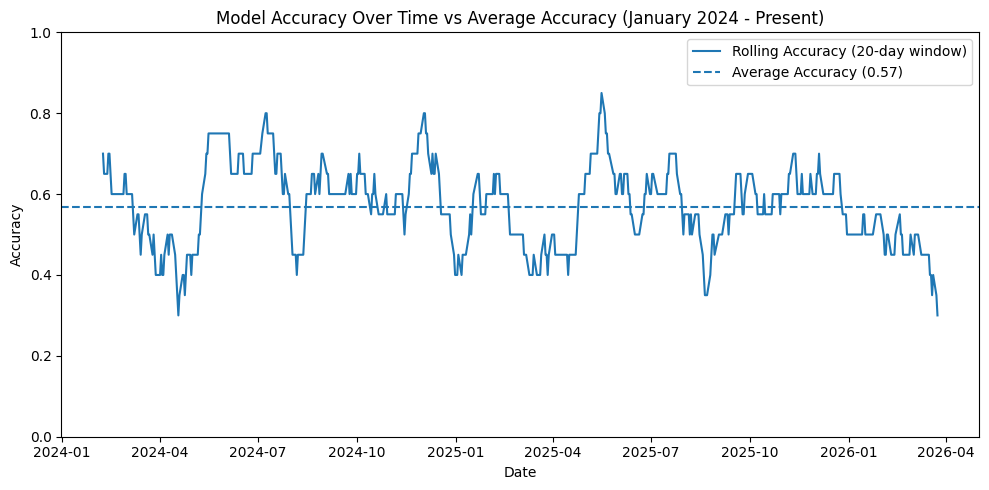

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Build results dataframe
results = pd.DataFrame({
    "Date": df.iloc[y_test.index]["Date"].values,
    "Actual": y_test.values,
    "Predicted": preds
})

# Correct predictions
results["Correct"] = (results["Actual"] == results["Predicted"]).astype(int)

# Rolling accuracy
results["rolling_accuracy"] = results["Correct"].rolling(window=20).mean()

# Average accuracy
avg_accuracy = results["Correct"].mean()

# Plot
plt.figure(figsize=(10, 5))

# Rolling accuracy line
plt.plot(results["Date"], results["rolling_accuracy"], label="Rolling Accuracy (20-day window)")

# Average accuracy line
plt.axhline(avg_accuracy, linestyle="--", label=f"Average Accuracy ({avg_accuracy:.2f})")

# Labels
plt.title("Model Accuracy Over Time vs Average Accuracy (January 2024 - Present)")
plt.xlabel("Date")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

# Legend
plt.legend()

plt.tight_layout()
plt.show()

## Visualization Rationale

The visualization shows model accuracy over time using a rolling 20-day window, along with a horizontal line representing the average accuracy across the entire test period. This design was chosen to make the model’s performance easy to interpret for a general audience. The rolling accuracy highlights how predictive performance changes over time, which is important because financial markets are dynamic and model effectiveness can vary across different conditions. The inclusion of the average accuracy provides a clear benchmark, allowing viewers to quickly assess whether the model is performing above or below its typical level. A line chart is appropriate because it emphasizes trends and temporal patterns, making the results more intuitive and informative than a static summary metric.

## Conclusion

This project demonstrates how historical financial data can be transformed into a structured dataset and used to build a predictive model for next-day market direction. By combining data engineering, relational modeling, and machine learning, the pipeline provides a complete workflow from raw data to actionable insights. While the model does not achieve perfect accuracy, the results show that there is some predictive signal in historical market behavior. More importantly, the project highlights how data-driven approaches can help investors better understand market trends and make more informed decisions. Future improvements could include incorporating additional data sources, testing more advanced models, and evaluating performance across different market conditions to further enhance predictive accuracy.